## Start Spark

In [3]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date

# Start Spark with your memory configuration
spark = SparkSession.builder \
    .appName("Drought_EDA") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print("Spark is ready for EDA!")

Spark is ready for EDA!


## Read, Join, and Draw the Heatmap

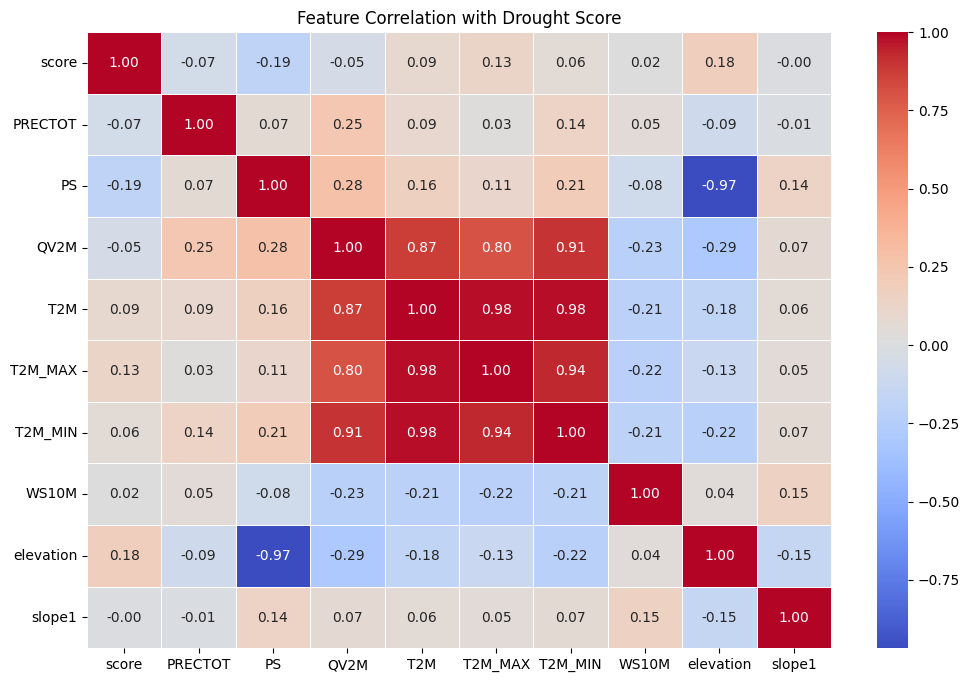

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, to_date

# 1. Load the original datasets using your exact paths
path_soil = "file:///D:/ITC/Year 4/Semester II/Parallel/TP/Final Project/dataset/soil_data.csv"
path_train = "file:///D:/ITC/Year 4/Semester II/Parallel/TP/Final Project/dataset/train_timeseries/train_timeseries.csv"

soil_df = spark.read.csv(path_soil, header=True, inferSchema=True)
train_df = spark.read.csv(path_train, header=True, inferSchema=True)

# 2. Join and clean them quickly
joined_df = train_df.join(soil_df, on="fips", how="left")
cleaned_df = joined_df.withColumn("date", to_date(col("date"), "yyyy-MM-dd")).dropna(subset=["score"])

# 3. Grab a random 5% sample so it doesn't crash your computer's RAM
sample_df = cleaned_df.sample(fraction=0.05, seed=42)

# 4. Convert just this tiny sample to a Pandas DataFrame
pdf = sample_df.toPandas()

# 5. Select columns for the correlation matrix
cols_to_check = ['score', 'PRECTOT', 'PS', 'QV2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS10M', 'elevation', 'slope1']
corr_matrix = pdf[cols_to_check].corr()

# 6. Draw the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation with Drought Score")
plt.show()

In [5]:
# Print all column names in the joined dataset
print(cleaned_df.columns)

['fips', 'date', 'PRECTOT', 'PS', 'QV2M', 'T2M', 'T2MDEW', 'T2MWET', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'TS', 'WS10M', 'WS10M_MAX', 'WS10M_MIN', 'WS10M_RANGE', 'WS50M', 'WS50M_MAX', 'WS50M_MIN', 'WS50M_RANGE', 'score', 'lat', 'lon', 'elevation', 'slope1', 'slope2', 'slope3', 'slope4', 'slope5', 'slope6', 'slope7', 'slope8', 'aspectN', 'aspectE', 'aspectS', 'aspectW', 'aspectUnknown', 'WAT_LAND', 'NVG_LAND', 'URB_LAND', 'GRS_LAND', 'FOR_LAND', 'CULTRF_LAND', 'CULTIR_LAND', 'CULT_LAND', 'SQ1', 'SQ2', 'SQ3', 'SQ4', 'SQ5', 'SQ6', 'SQ7']


## Feature Selection

Pick every single column that scores higher than 0.05 or lower than -0.05 against the score.

### Heatmap 1: Advanced Weather & Wind

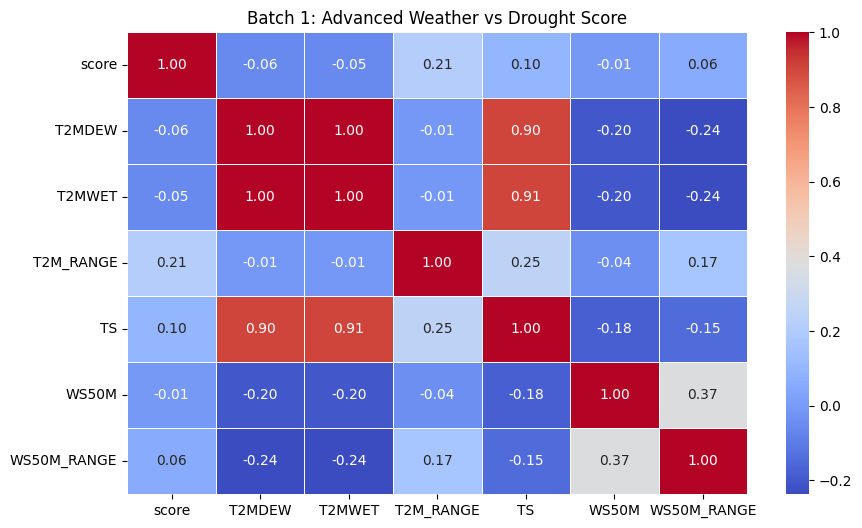

In [6]:
# Batch 1: Advanced Weather
cols_to_check_1 = ['score', 'T2MDEW', 'T2MWET', 'T2M_RANGE', 'TS', 'WS50M', 'WS50M_RANGE']

plt.figure(figsize=(10, 6))
sns.heatmap(pdf[cols_to_check_1].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Batch 1: Advanced Weather vs Drought Score")
plt.show()

['T2MDEW', 'T2MWET', 'T2M_RANGE', 'TS', 'WS50M_RANGE']

### Heatmap 2: Geography & Land Cover

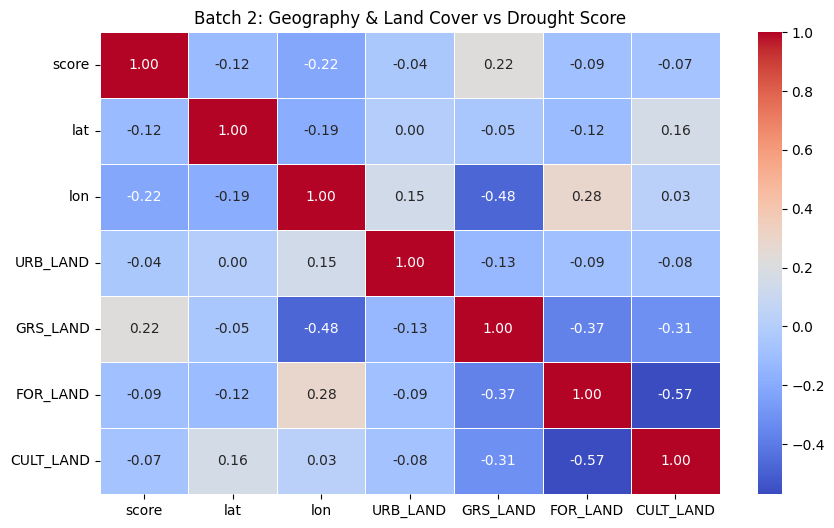

In [7]:
# Batch 2: Geography and Land Cover
cols_to_check_2 = ['score', 'lat', 'lon', 'URB_LAND', 'GRS_LAND', 'FOR_LAND', 'CULT_LAND']

plt.figure(figsize=(10, 6))
sns.heatmap(pdf[cols_to_check_2].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Batch 2: Geography & Land Cover vs Drought Score")
plt.show()

['lat', 'lon', 'GRS_LAND', 'FOR_LAND', 'CULT_LAND']


['T2MDEW', 'T2MWET', 'T2M_RANGE', 'TS', 'WS50M_RANGE']

### Heatmap 3: Soil Quality

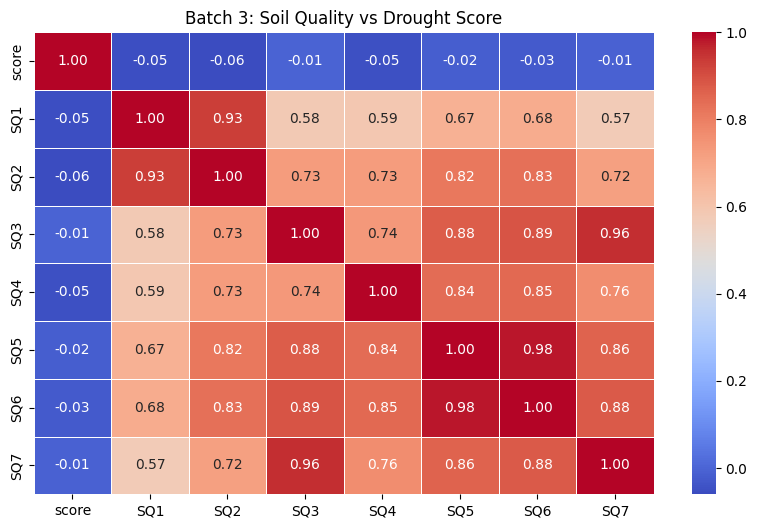

In [8]:
# Batch 3: Soil Quality Indicators
cols_to_check_3 = ['score', 'SQ1', 'SQ2', 'SQ3', 'SQ4', 'SQ5', 'SQ6', 'SQ7']

plt.figure(figsize=(10, 6))
sns.heatmap(pdf[cols_to_check_3].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Batch 3: Soil Quality vs Drought Score")
plt.show()

### Heatmap 4: The Rest of the Slopes and Angles

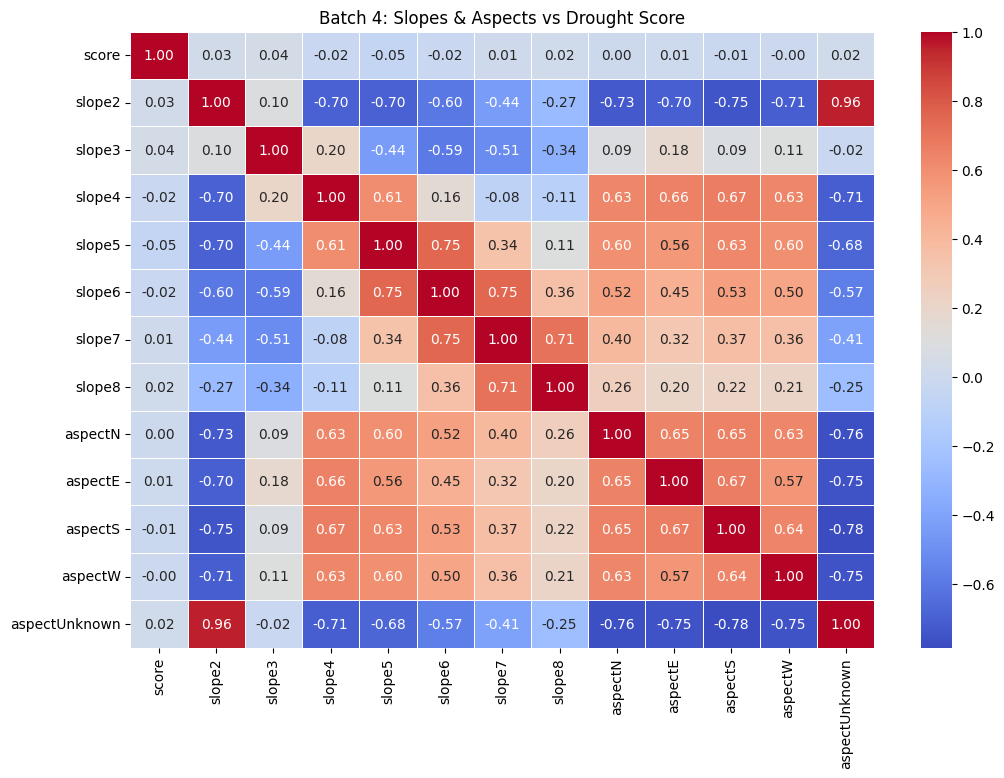

In [9]:
# Batch 4: Remaining Slopes and Angles
cols_to_check_4 = ['score', 'slope2', 'slope3', 'slope4', 'slope5', 'slope6', 'slope7', 'slope8', 'aspectN', 'aspectE', 'aspectS', 'aspectW', 'aspectUnknown']

plt.figure(figsize=(12, 8))
sns.heatmap(pdf[cols_to_check_4].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Batch 4: Slopes & Aspects vs Drought Score")
plt.show()

### Heatmap 5: The Rest of the Wind and Land

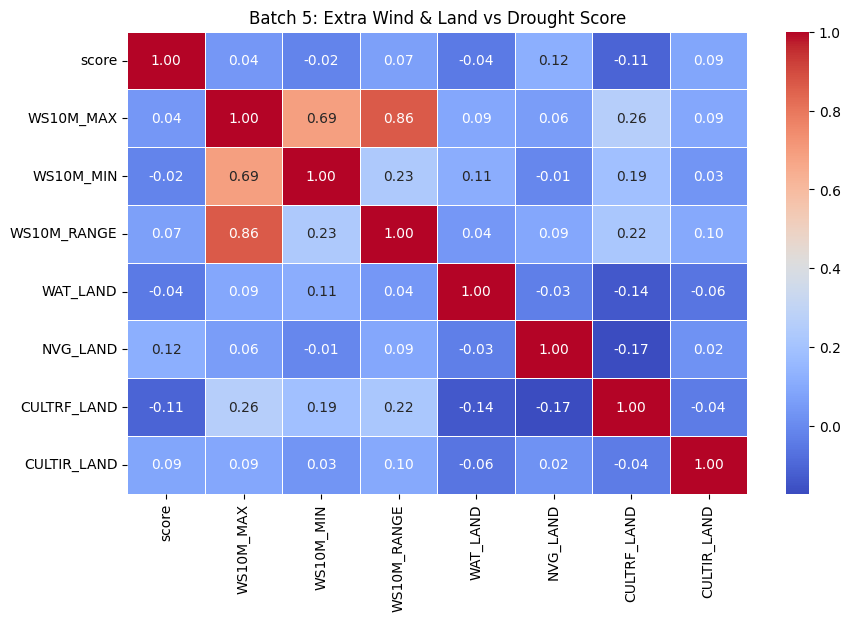

In [10]:
# Batch 5: Remaining Wind and Land Types
cols_to_check_5 = ['score', 'WS10M_MAX', 'WS10M_MIN', 'WS10M_RANGE', 'WAT_LAND', 'NVG_LAND', 'CULTRF_LAND', 'CULTIR_LAND']

plt.figure(figsize=(10, 6))
sns.heatmap(pdf[cols_to_check_5].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Batch 5: Extra Wind & Land vs Drought Score")
plt.show()

['WS10M_RANGE', 'N'GV_LAND', 'CULTRF_LAND', 'C'ULTIR_LAND']


['lat', 'lon', 'GRS_LAND', 'FOR_LAND', 'CULT_LAND']


['T2MDEW', 'T2MWET', 'T2M_RANGE', 'TS', 'WS50M_RANGE']

Final Features: 

['WS10M_RANGE', 'N'GV_LAND', 'CULTRF_LAND', 'C'ULTIR_LAND' 'lat', 'lon', 'GRS_LAND', 'FOR_LAND', 'CULT_LAND', 'T2MDEW', 'T2MWET', 'T2M_RANGE', 'TS', 'WS50M_RANGE']

In [11]:
feature_columns = [
    'PS', 'elevation', 'T2M_MAX', 'QV2M', 
    'WS10M_RANGE', 'NVG_LAND', 'CULTRF_LAND', 'CULTIR_LAND', 
    'lat', 'lon', 'GRS_LAND', 'FOR_LAND', 'CULT_LAND', 
    'T2MDEW', 'T2MWET', 'T2M_RANGE', 'TS', 'WS50M_RANGE'
]